In [26]:
from PIL import Image, ImageDraw, ImageFont
import os

def concat_images_with_titles(image_paths, titles, save_path):
    assert len(image_paths) == len(titles)

    images = [Image.open(p).convert("RGB") for p in image_paths]
    width, height = images[0].size

    # ====== 字体大小（更大一点）======
    font_size = int(width * 0.1)   # 🔥 再放大一点（2560 → 256）

    # ====== 字体路径（关键修复点）======
    font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"

    if not os.path.exists(font_path):
        raise ValueError("❌ 找不到字体文件，请检查路径")

    font = ImageFont.truetype(font_path, font_size)

    # ====== 标题区域 ======
    title_height = int(height * 0.18)

    total_width = width * len(images)
    total_height = height + title_height

    new_img = Image.new("RGB", (total_width, total_height), (255, 255, 255))
    draw = ImageDraw.Draw(new_img)

    x_offset = 0
    for img, title in zip(images, titles):

        new_img.paste(img, (x_offset, title_height))

        bbox = draw.textbbox((0, 0), title, font=font)
        text_w = bbox[2] - bbox[0]
        text_h = bbox[3] - bbox[1]

        text_x = x_offset + (width - text_w) // 2
        text_y = (title_height - text_h) // 2

        # ====== 粗体+清晰 ======
        draw.text(
            (text_x, text_y),
            title,
            font=font,
            fill=(0, 0, 0),
            stroke_width=4,
            stroke_fill=(0, 0, 0)
        )

        x_offset += width

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    new_img.save(save_path)

    print(f"✅ 完成: {save_path}")


# ===== 直接用你的数据 =====
if __name__ == "__main__":
    image_paths = [
        "/shared_data/users/yili/Hybrid-Mamba-UNet/data/Real_Fundus/input/00015.PNG",
        "/shared_data/users/yili/Hybrid-Mamba-UNet/data/Real_Fundus/gt/00015.PNG",
        "/shared_data/users/yili/Hybrid-Mamba-UNet/data/res/ArcNet/00015.PNG",
        "/shared_data/users/yili/Hybrid-Mamba-UNet/data/res/ArcNet/00015.PNG",
       "/shared_data/users/yili/Hybrid-Mamba-UNet/data/res/ArcNet/00015.PNG",
        "/shared_data/users/yili/Hybrid-Mamba-UNet/data/res/ArcNet/00015.PNG",
        "/shared_data/users/yili/Hybrid-Mamba-UNet/data/res/ArcNet/00015.PNG",
        "/shared_data/users/yili/Hybrid-Mamba-UNet/baseline_code/work_fundus_mamba/infer_out/00015.PNG"
    ]

    titles = [
        "Input","GT","I-SECRET","PCE-Net",
        "SCRNet","ArcNet","LED","Ours"
    ]
# 117   95  88  84 80 72 55
    concat_images_with_titles(image_paths, titles, "result/00015_compare.png")

✅ 完成: result/00015_compare.png


In [13]:
from PIL import Image, ImageDraw, ImageFont, ImageFile
import os

# 允许加载截断的 PNG 图像（避免 OSError）
ImageFile.LOAD_TRUNCATED_IMAGES = True

def concat_images_with_titles(image_paths, titles, save_path):
    assert len(image_paths) == len(titles)

    images = []
    for p in image_paths:
        try:
            img = Image.open(p).convert("RGB")
            img.load()  # 强制完全加载
            images.append(img)
        except Exception as e:
            print(f"⚠️ 警告：无法读取图片 {p}")
            print(f"   错误：{e}")
            # 如果无法读取，创建一个空白图代替
            if images:
                images.append(Image.new("RGB", images[0].size, (128, 128, 128)))
            else:
                images.append(Image.new("RGB", (512, 512), (128, 128, 128)))

    width, height = images[0].size

    font_size = int(width * 0.1)

    font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"

    if not os.path.exists(font_path):
        raise ValueError("❌ 找不到字体文件，请检查路径")

    font = ImageFont.truetype(font_path, font_size)

    title_height = int(height * 0.18)

    # ===== 仅这里改动：改成 2 行 4 列 =====
    cols = 4
    rows = 2

    total_width = width * cols
    total_height = (height + title_height) * rows

    new_img = Image.new("RGB", (total_width, total_height), (255, 255, 255))
    draw = ImageDraw.Draw(new_img)

    for idx, (img, title) in enumerate(zip(images, titles)):

        row = idx // cols
        col = idx % cols

        x_offset = col * width
        y_offset = row * (height + title_height)

        # 粘贴图片
        new_img.paste(img, (x_offset, y_offset + title_height))

        bbox = draw.textbbox((0, 0), title, font=font)
        text_w = bbox[2] - bbox[0]
        text_h = bbox[3] - bbox[1]

        text_x = x_offset + (width - text_w) // 2
        text_y = y_offset + (title_height - text_h) // 2

        draw.text(
            (text_x, text_y),
            title,
            font=font,
            fill=(0, 0, 0),
            stroke_width=4,
            stroke_fill=(0, 0, 0)
        )

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    new_img.save(save_path)

    print(f"✅ 完成：{save_path}")


if __name__ == "__main__":

    titles = [
        "Input","GT","PCE-Net",
        "SCRNet","ArcNet","LED","I-SECRET","Ours"
    ]

    # 从第 91 张开始（索引从 0 开始，所以是 range(90, 120)）
    for i in range(0, 120):
        name = f"{i+1:05d}_mask.png"

        image_paths = [
            f"/shared_data/users/yili/Hybrid-Mamba-UNet/data/Real_Fundus/input_mask/{name}",
            f"/shared_data/users/yili/Hybrid-Mamba-UNet/data/Real_Fundus/gt_mask/{name}",
            f"/shared_data/users/yili/Hybrid-Mamba-UNet/data/res/PCENet_mask/{name}",
            f"/shared_data/users/yili/Hybrid-Mamba-UNet/data/res/SCRNet_mask/{name}",
            f"/shared_data/users/yili/Hybrid-Mamba-UNet/data/res/ArcNet_mask/{name}",
            f"/shared_data/users/yili/Hybrid-Mamba-UNet/data/res/LED_mask/{name}",
            f"/shared_data/users/yili/Hybrid-Mamba-UNet/data/res/I_SECRET_mask/{name}",
            f"/shared_data/users/yili/Hybrid-Mamba-UNet/data/Real_Fundus/infer_out_mask/{name}"
        ]

        save_path = f"result_compare_mask/{name}"

        try:
            concat_images_with_titles(image_paths, titles, save_path)
        except Exception as e:
            print(f"❌ 处理 {name} 时出错：{e}")
            continue


✅ 完成：result_compare_mask/00001_mask.png
✅ 完成：result_compare_mask/00002_mask.png
✅ 完成：result_compare_mask/00003_mask.png
✅ 完成：result_compare_mask/00004_mask.png
✅ 完成：result_compare_mask/00005_mask.png
✅ 完成：result_compare_mask/00006_mask.png
✅ 完成：result_compare_mask/00007_mask.png
✅ 完成：result_compare_mask/00008_mask.png
✅ 完成：result_compare_mask/00009_mask.png
✅ 完成：result_compare_mask/00010_mask.png
✅ 完成：result_compare_mask/00011_mask.png
✅ 完成：result_compare_mask/00012_mask.png
✅ 完成：result_compare_mask/00013_mask.png
✅ 完成：result_compare_mask/00014_mask.png
✅ 完成：result_compare_mask/00015_mask.png
✅ 完成：result_compare_mask/00016_mask.png
✅ 完成：result_compare_mask/00017_mask.png
✅ 完成：result_compare_mask/00018_mask.png
✅ 完成：result_compare_mask/00019_mask.png
✅ 完成：result_compare_mask/00020_mask.png
✅ 完成：result_compare_mask/00021_mask.png
✅ 完成：result_compare_mask/00022_mask.png
✅ 完成：result_compare_mask/00023_mask.png
✅ 完成：result_compare_mask/00024_mask.png
✅ 完成：result_compare_mask/00025_mask.png


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

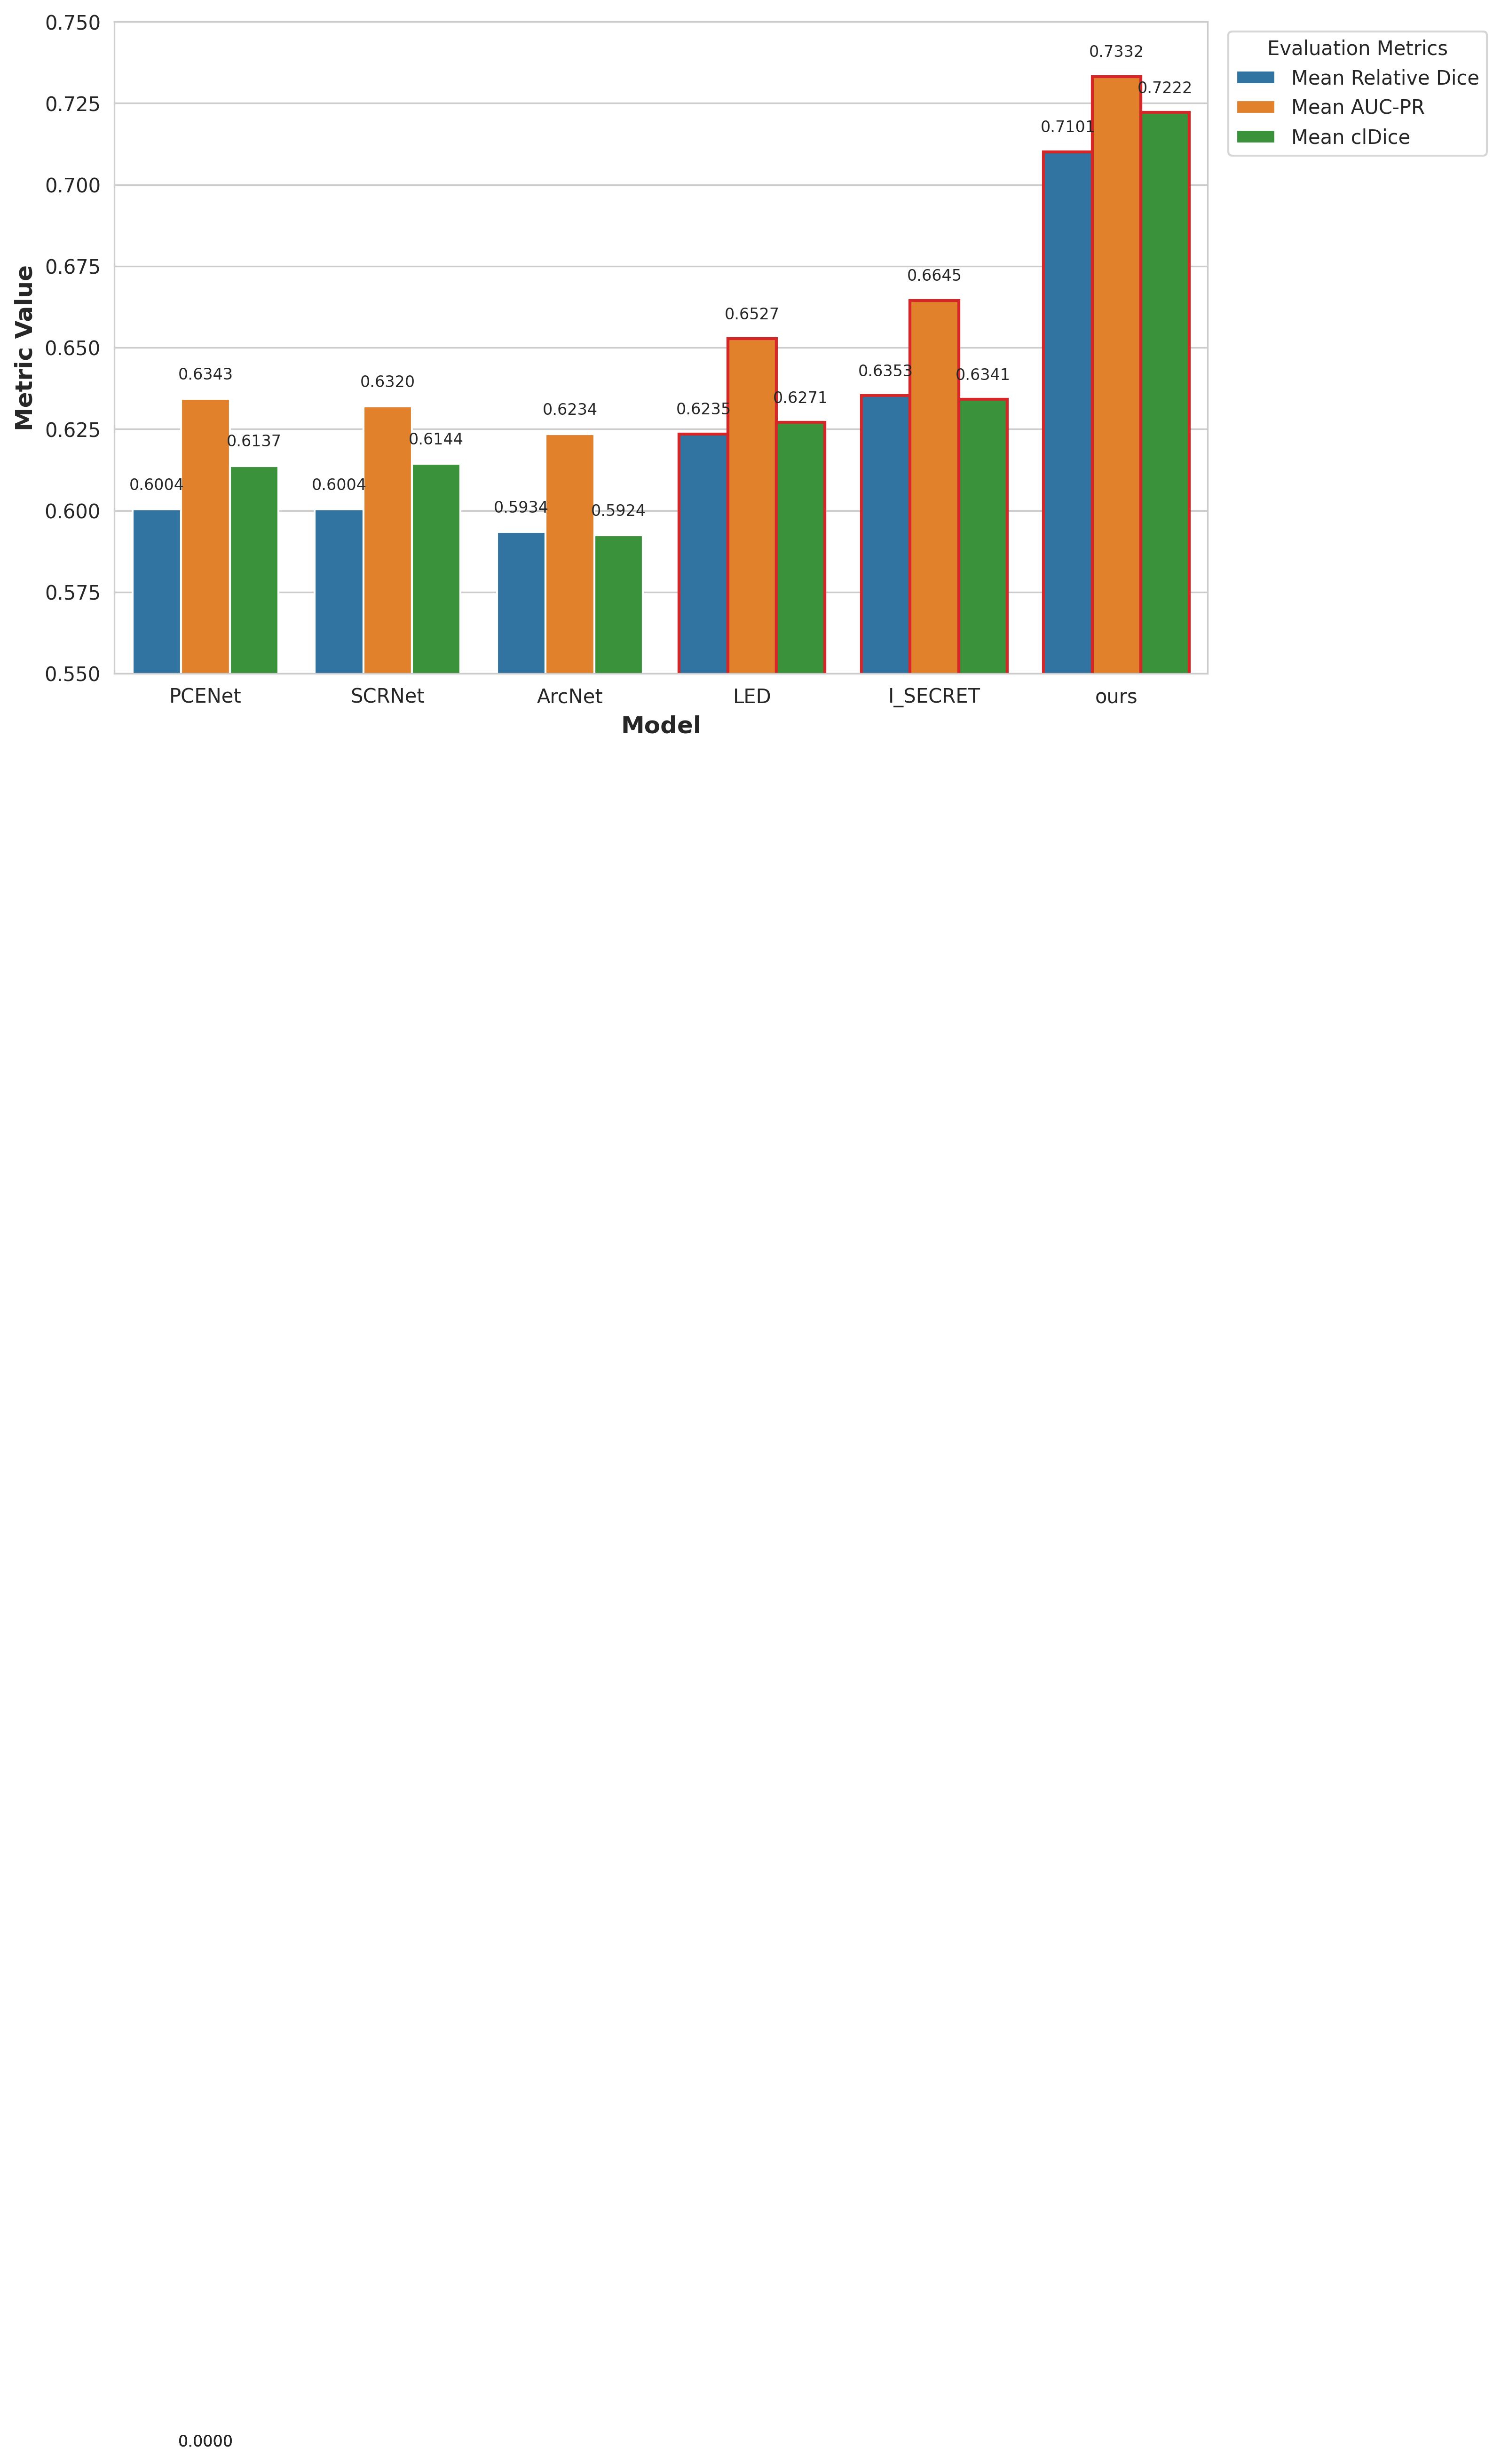

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 录入您的精准数据
data = {
    "模型名称": ["PCENet", "PCENet", "PCENet",
                "SCRNet", "SCRNet", "SCRNet",
                "ArcNet", "ArcNet", "ArcNet",
                "LED", "LED", "LED",
                "I_SECRET", "I_SECRET", "I_SECRET",
                "ours", "ours", "ours"],
    "评价指标": ["Mean Relative Dice", "Mean AUC-PR", "Mean clDice"] * 6,
    "数值": [0.6004, 0.6343, 0.6137,
            0.6004, 0.6320, 0.6144,
            0.5934, 0.6234, 0.5924,
            0.6235, 0.6527, 0.6271,
            0.6353, 0.6645, 0.6341,
            0.7101, 0.7332, 0.7222]
}
df = pd.DataFrame(data)

# 2. 学术绘图风格设置（顶刊标准）
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

# 3. 绘制分组柱状图
plt.figure(figsize=(10, 6), dpi=300)
palette = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # 专业学术配色
ax = sns.barplot(x="模型名称", y="数值", hue="评价指标", data=df, palette=palette)

# 4. 突出ours模型（红色描边）
for patch in ax.patches:
    # 定位ours模型的柱子
    if patch.get_x() >= 5 * (patch.get_width() + 0.2):
        patch.set_edgecolor("#d62728")
        patch.set_linewidth(1.5)

# 5. 柱子顶部标注精准数值
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 0.005,
            f"{height:.4f}", ha="center", va="bottom", fontsize=8)

# 6. 图表细节优化
ax.set_ylim(0.55, 0.75)  # 适配数值范围，突出差距
ax.set_xlabel("Model", fontweight="bold")
ax.set_ylabel("Metric Value", fontweight="bold")
ax.legend(title="Evaluation Metrics", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()  # 自动适配布局，避免文字截断

# 7. 保存矢量图+高清图（投稿专用）
plt.savefig("model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.savefig("model_performance_comparison.pdf", bbox_inches="tight")  # 矢量图，投稿首选
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def create_high_res_comparison_figure(input_image_path, output_image_path):
    # 1. 加载原图 (请确保输入的是您那张排版好的 2x4 纯净拼图)
    img = Image.open(input_image_path)
    img_w, img_h = img.size

    # 2. 设置极高分辨率画布
    # 目标分辨率: 10240 x 6040
    # 公式: figsize(宽, 高) * dpi = 像素分辨率
    # 增加一点底部高度留给文字，假设图身占 5500，底部文字占 540
    fig, ax = plt.subplots(figsize=(102.4, 60.4), dpi=100)

    # 铺满画布，去掉坐标轴留白
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0.08)
    ax.imshow(img)
    ax.axis('off') # 关闭坐标轴

    # ==========================================
    # 3. 绘制局部放大框和箭头 (坐标需要您根据实际图片微调)
    # 坐标系说明：左上角为 (0,0)，右下角为 (img_w, img_h)
    # ==========================================

    # 示例 1: GT的绿色参考框 (假设在第一排第二个子图的右下角)
    # patches.Rectangle((x, y), 宽, 高)
    rect_gt = patches.Rectangle((4000, 2000), 800, 800, linewidth=8, edgecolor='green', facecolor='none')
    ax.add_patch(rect_gt)

    # 示例 2: PCE-Net的黄色箭头 (指出过曝光区域)
    # ax.annotate('文本', xy=(箭头尖端), xytext=(文本位置), arrowprops=dict(箭头样式))
    ax.annotate('Overexposure\nArtifacts',
                xy=(6200, 1800), xytext=(6800, 2200),
                color='white', weight='bold', fontsize=70, ha='center',
                bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="none", alpha=0.6),
                arrowprops=dict(facecolor='yellow', edgecolor='black', shrink=0.05, width=15, headwidth=45))

    # 示例 3: LED的黄色畸变框 (假设在第二排第二个子图)
    rect_led = patches.Rectangle((3200, 4800), 800, 800, linewidth=8, edgecolor='yellow', facecolor='none')
    ax.add_patch(rect_led)
    ax.text(3600, 5800, 'Over-smoothing &\nStructural Distortion\n(SSIM: 0.7325↓)',
            color='white', weight='bold', fontsize=70, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="none", alpha=0.6))

    # 示例 4: Ours的红色高保真框 (假设在第二排第四个子图)
    rect_ours = patches.Rectangle((8300, 4800), 800, 800, linewidth=10, edgecolor='red', facecolor='none')
    ax.add_patch(rect_ours)

    # 画一条红线连接原图位置和右上角的“放大视图”（如果您图里有放大的小方块的话）
    # ax.plot([8700, 9500], [4800, 3500], color='red', linewidth=6)

    ax.text(9200, 5800, 'High-Fidelity\nCapillary Network\nReconstruction\n(PSNR: 29.9000↑)',
            color='white', weight='bold', fontsize=70, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="none", alpha=0.6))

    # ==========================================
    # 4. 底部学术图注文字 (Figure Caption)
    # ==========================================
    caption_title = "Fig. 1. Quantitative and Qualitative Comparison of Fundus Image Restoration for Enhanced Microvasculature Analysis."
    caption_legend = "Red Box = Topology Restoration & High Fidelity; Yellow Arrow = Artifacts; Yellow Box = Over-smoothing; Green Box = GT Reference."

    # 使用 fig.text 绝对定位底部文字
    fig.text(0.5, 0.04, caption_title, ha='center', va='center', fontsize=90, fontname='Times New Roman')
    fig.text(0.5, 0.015, caption_legend, ha='center', va='center', fontsize=80, fontname='Times New Roman', color='dimgray')

    # 5. 保存极高分辨率图像
    plt.savefig(output_image_path, dpi=100, bbox_inches='tight', pad_inches=0.1)
    print(f"✅ 高清标注图已成功保存至: {output_image_path} (分辨率: {fig.get_size_inches()[0]*100} x {fig.get_size_inches()[1]*100})")

# 运行代码
if __name__ == '__main__':
    # 替换为您本地的图片路径
    input_image = '/shared_data/users/yili/Hybrid-Mamba-UNet/result_compare_raw/00047.PNG'
    output_image = '/shared_data/users/yili/Hybrid-Mamba-UNet/00047.PNG'
    create_high_res_comparison_figure(input_image, output_image)
    pass